In [2]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import output
from base64 import b64decode
import os
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# 2. LOAD MODEL
# ==========================================
model_path = '/content/drive/MyDrive/Face_Attendance_Model/face_recognition_resnet.keras'

if os.path.exists(model_path):
    model = load_model(model_path)
    print("ResNet Model loaded successfully!")
else:
    print(" Error: Model file not found. Check the path!")
    
class_names = ['Abir', 'DIPANKAR', 'Mehedi']

ResNet Model loaded successfully!


In [ ]:
# ==========================================
# 3. SETUP FACE DETECTOR (FIXED)
# ==========================================
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)

if face_cascade.empty():
    print(" Error: Could not load Face Detector XML!")
else:
    print("Face Detector loaded successfully.")

Face Detector loaded successfully.


In [7]:
# ==========================================
# 4. WEBCAM CAPTURE FUNCTION
# ==========================================
def capture_image_from_webcam():
    js_code = """
    async function captureImage() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');
      const canvas = document.createElement('canvas');

      div.style.textAlign = 'center';
      video.style.border = '2px solid black';
      button.textContent = '📸 Capture';
      button.style.fontSize = '20px';
      button.style.marginTop = '10px';

      div.appendChild(video);
      div.appendChild(button);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({ video: true });
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise(resolve => button.onclick = resolve);

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/png');
    }
    captureImage();
    """

    print("Camera opening below...")
    print(" Position your face and click CAPTURE")

    try:
        data = output.eval_js(js_code)
        binary = b64decode(data.split(',')[1])
        with open('captured_face.png', 'wb') as f:
            f.write(binary)
        print("Photo captured!")

        # Read image using OpenCV
        img = cv2.imread('captured_face.png')
        return img
    except Exception as e:
        print(f"Camera error: {e}")
        return None

In [ ]:
# ===============================
# 5️⃣ FACE PREPROCESSING 
# ===============================
# Ensure Haar Cascade is loaded
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)

def preprocess_face_for_resnet(img):
    # 1. Convert to RGB for the model 
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Convert to Gray ONLY for detection 
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Detect Face
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))

    face_crop = None
    face_rect_viz = img_rgb.copy() # For visualization only

    if len(faces) > 0:
        # Get largest face
        largest = max(faces, key=lambda f: f[2] * f[3])
        x, y, w, h = largest

        # Draw box for visualization
        cv2.rectangle(face_rect_viz, (x, y), (x+w, y+h), (0, 255, 0), 3)

        # Add Padding
        pad = 20
        x = max(0, x - pad)
        y = max(0, y - pad)
        w = min(w + 2*pad, img.shape[1] - x)
        h = min(h + 2*pad, img.shape[0] - y)

        face_crop = img_rgb[y:y+h, x:x+w]
        print("Face detected & cropped")
    else:
        print(" No face found → using center crop")
        h, w, _ = img.shape
        size = min(h, w) - 50
        y0, x0 = (h - size) // 2, (w - size) // 2
        face_crop = img_rgb[y0:y0+size, x0:x0+size]

    # 4. Resize to 224x224 (REQUIRED for ResNet)
    face_resized = cv2.resize(face_crop, (224, 224))

    # 5. Preprocess (ResNet specific math)
    from tensorflow.keras.applications.resnet50 import preprocess_input
    face_input = np.expand_dims(face_resized, axis=0) # Shape: (1, 224, 224, 3)
    face_input = preprocess_input(face_input)

    return face_input, face_rect_viz, face_crop, face_resized

Camera opening below...
 Position your face and click CAPTURE
Photo captured!
Face detected & cropped
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


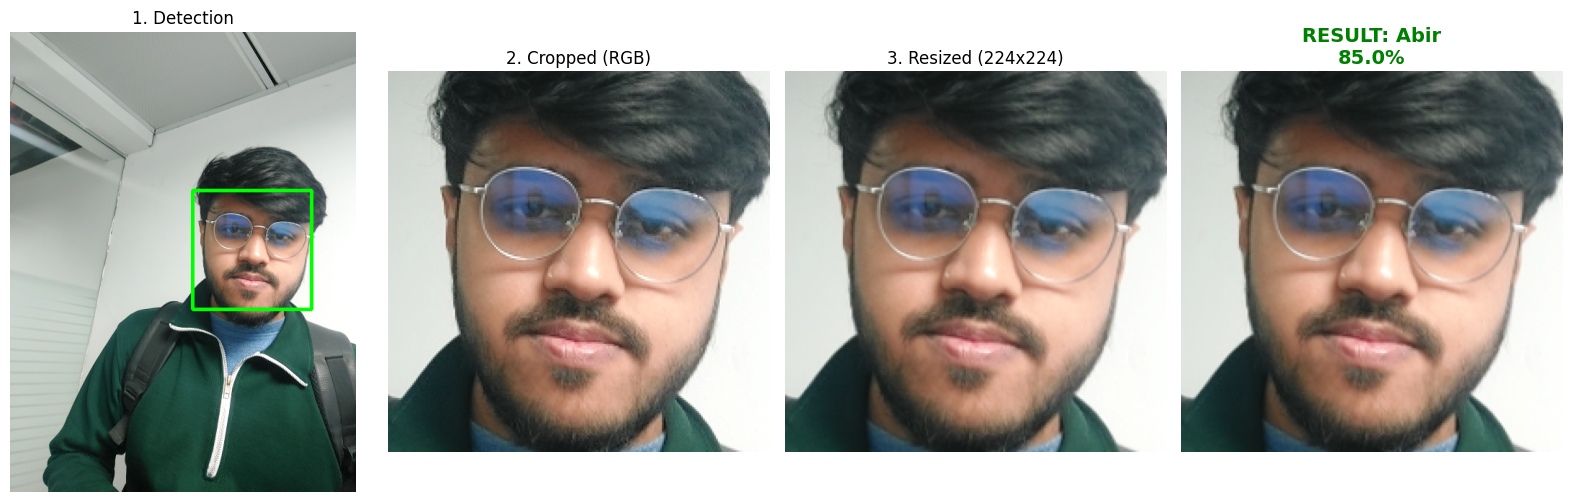

 ATTENDANCE MARKED: ABIR


In [11]:
# ===============================
# 6️⃣ RUN ATTENDANCE
# ===============================
raw_img = capture_image_from_webcam()

if raw_img is not None:
    try:
        # Run Pipeline
        face_input, img_with_box, cropped, resized = preprocess_face_for_resnet(raw_img)

        # Predict
        prediction = model.predict(face_input)
        predicted_idx = np.argmax(prediction)
        confidence = np.max(prediction) * 100
        predicted_name = class_names[predicted_idx]

        # ===============================
        # DISPLAY PIPELINE
        # ===============================
        plt.figure(figsize=(16, 5))

        # 1. Raw Capture with Face Box
        plt.subplot(1, 4, 1)
        plt.imshow(img_with_box)
        plt.title("1. Detection")
        plt.axis('off')

        # 2. Cropped Face
        plt.subplot(1, 4, 2)
        plt.imshow(cropped)
        plt.title("2. Cropped (RGB)")
        plt.axis('off')

        # 3. Resized Input
        plt.subplot(1, 4, 3)
        plt.imshow(resized)
        plt.title("3. Resized (224x224)")
        plt.axis('off')

        # 4. Prediction Result
        plt.subplot(1, 4, 4)
        plt.imshow(resized) # Showing the face again for context
        color = 'green' if confidence > 70 else 'red'
        plt.title(f"RESULT: {predicted_name}\n{confidence:.1f}%",
                  color=color, fontsize=14, fontweight='bold')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        # ===============================
        # FINAL DECISION
        # ===============================
        if confidence > 70:
            print(f" ATTENDANCE MARKED: {predicted_name.upper()}")
        else:
            print(" Low confidence — try again")

    except Exception as e:
        print(f" ERROR: {e}")